### **RAG : RETERIVAL AUGEMENTED GENERATION**

> Retrieval-Augmented Generation (RAG) is an artificial intelligence framework that improves the quality, accuracy, and reliability of large language models (LLMs) by grounding them in external knowledge bases.

<br>

> Instead of an LLM relying solely on the information it was originally trained on, a RAG system works in two steps:


1. **Retrieval**: It searches an external database or document collection to find relevant facts related to the user's prompt.

2. **Generation:** It feeds those retrieved facts into the LLM to help it generate a highly accurate and context-specific final response.



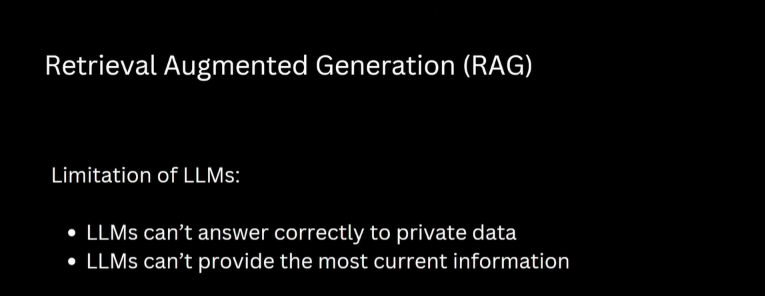

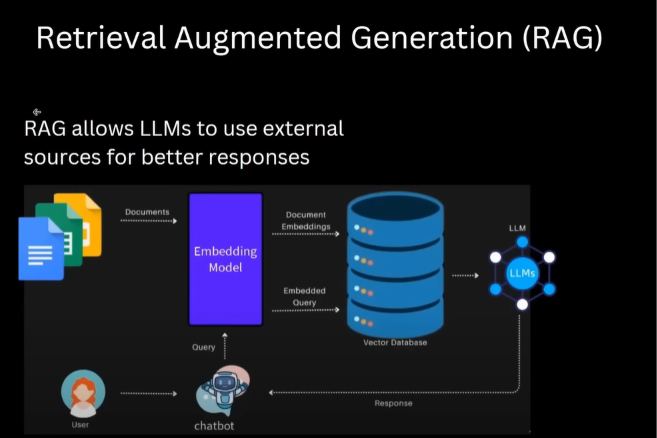

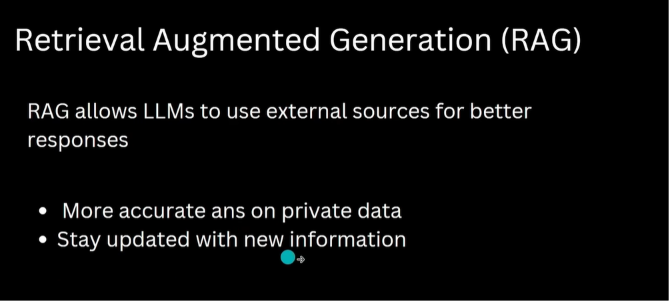

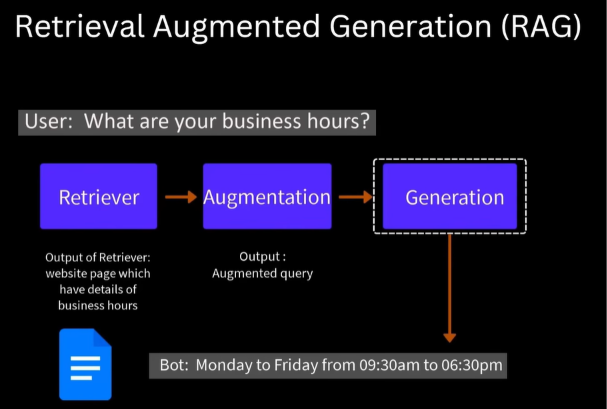

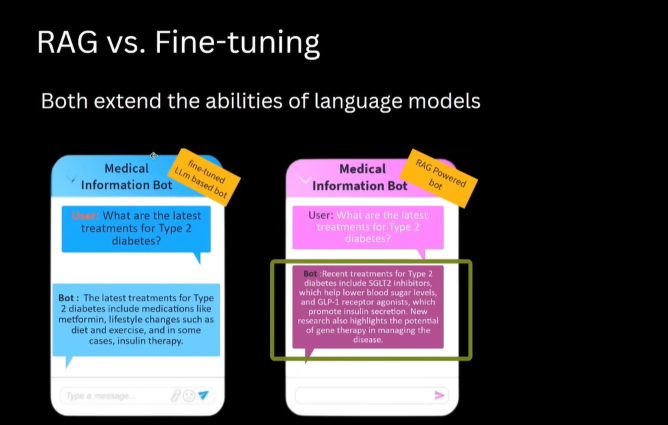

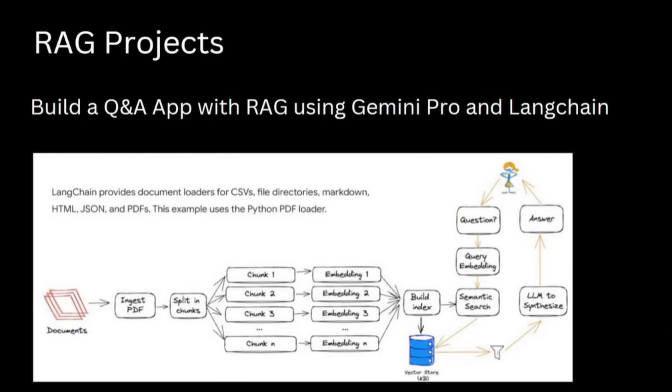

### **The Processes in Any Project and Workflow with RAG**

**Step 1: Load Data**
Use LangChain to load the data. Utilize `PyPDFLoader` from `document_loaders`.

**Step 2: Inspect Data**
Load the data and inspect its length and content.

**Step 3: Chunking**
Break the data into chunks using `text_splitters`. Specifically, use `RecursiveCharacterTextSplitter` to split the text into smaller documents.

**Step 4: Create Embeddings**
Create embeddings using Chroma or HuggingFace Transformers. You can use a model like `"all-MiniLM-L6-v2"`.

**Step 5: Test Embeddings (Optional)**
Create a vector using:
`embeddings.embed_query("Hello World")`

**Step 6: Create Vector Stores**
Create a vector store to hold the embeddings:
`Chroma.from_documents(documents=..., embedding=...)`

**Step 7: Create a Retriever**
Set up a retriever to fetch the relevant data or queries:
`vector_stores.as_retriever(search_type='similarity', search_kwargs={"k": 19})`

**Step 8: Define the LLM**
Create and initialize an LLM model (either a local model or via an API).

**Step 9: Design a Prompt Template**
Design a prompt template for chaining the LLM and the retriever. Import the necessary tools from LangChain:
*   `create_retrieval_chain`
*   `create_stuff_documents_chain`
*   `ChatPromptTemplate`

**Step 10: Create the Chains**
Tie everything together by creating a question-answer chain and the final RAG chain:
`question_answer_chain = create_stuff_documents_chain(llm, prompt)`
`rag_chain = create_retrieval_chain(retriever, question_answer_chain)`

**Step 11: Invoke and Print Response**
Run the chain by invoking it with your input question:
`response = rag_chain.invoke({"input": "WHAT QUESTION DO YOU WANT TO ASK"})`



```
[External Data / PDFs]
                 |
                 v
         [Text Splitter]
          (Data Chunks)
                 |
                 v
        [Embedding Model]
                 |
                 v
      [(Vector Store / Chroma)] <====== [Retriever] <========= [User Query]
                                            |                       |
                                            v                       v
                                    (Relevant Context)          (Question)
                                            \                       /
                                             \                     /
                                              v                   v
                                          [Prompt Template & Chain]
                                                      |
                                                      v
                                                    [LLM]
                                                      |
                                                      v
                                              [Final Response]
```



### **Step 12: Advanced Retrieval Techniques (Maximum Marginal Relevance - MMR)**

Standard similarity search can sometimes return highly redundant chunks if multiple sections of your documents discuss the same concept in similar terms.

**Maximum Marginal Relevance (MMR)** solves this by optimizing for both **relevance** to the user query and **diversity** among the retrieved results. It avoids feeding repetitive context to the LLM, making better use of your context window limits.

In [ ]:
# Example of setting up an MMR retriever in LangChain
# This replaces a standard similarity retriever to enforce variety in results

# retriever = vector_stores.as_retriever(
#     search_type="mmr",
#     search_kwargs={
#         "k": 5,           # Number of documents to return
#         "fetch_k": 20,    # Number of documents to pass to MMR algorithm initially
#         "lambda_mult": 0.5 # 0.0 for maximum diversity, 1.0 for minimum diversity (pure relevance)
#     }
# )

### **Step 13: RAG Evaluation**

Evaluating your pipeline is critical to ensure reliability. Rather than checking outputs manually, production RAG pipelines evaluate three core pillars:

1. **Generation Evaluation (Faithfulness & Answer Relevance)**:
   * **Faithfulness**: Is the generated answer grounded *only* in the retrieved context, or does the LLM hallucinate external information?
   * **Answer Relevance**: Does the final response directly address the user's initial question?

2. **Retrieval Evaluation (Context Precision & Recall)**:
   * **Context Precision**: Out of all retrieved chunks, how many were actually relevant to answering the question?
   * **Context Recall**: Did the retriever capture all the necessary facts required to form the correct answer?

*Tip: Frameworks like `Ragas` or `TruLens` can be integrated alongside LangChain to automatically score these metrics using a judge LLM.*